# データセットの作成

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = (
    REPO_ROOT
    / "A_Hawkes_Model_Approach_to_Modeling_Price_Spikes_in_the_Japanese_Electricity_Market"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4


In [ ]:
from pathlib import Path
import pandas as pd

base_path = RAW_DATA_DIR / "electricity"

dfs = []

for year in range(2016, 2022):  # 2016年度〜2021年度
    csv_path = base_path / f"spot_summary_{year}.csv"
    df_year = pd.read_csv(csv_path, encoding="cp932")
    dfs.append(df_year)

# 結合
df = pd.concat(dfs, ignore_index=True)

# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])
df = df[df["受渡日"].between("2016-04-01", "2022-03-31")].copy()

# 時刻コード → 30分刻み
df["datetime"] = df["受渡日"] + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")

# indexに設定
df = df.set_index("datetime").sort_index()

df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
datetime,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================================================
# 0. エリア列定義
# =========================================================
AREA_COLS = {
    "Hokkaido": "エリアプライス北海道(円/kWh)",
    "Tohoku": "エリアプライス東北(円/kWh)",
    "Tokyo": "エリアプライス東京(円/kWh)",
    "Chubu": "エリアプライス中部(円/kWh)",
    "Hokuriku": "エリアプライス北陸(円/kWh)",
    "Kansai": "エリアプライス関西(円/kWh)",
    "Chugoku": "エリアプライス中国(円/kWh)",
    "Shikoku": "エリアプライス四国(円/kWh)",
    "Kyushu": "エリアプライス九州(円/kWh)",
}


# =========================================================
# 1. 営業日/非営業日フラグ作成
#    論文どおり土日と日本の祝日を非営業日にする。
# =========================================================
def add_day_type_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # date列（正規化）
    out["date"] = pd.to_datetime(out["受渡日"]).dt.normalize()

    # weekday: Mon=0, ..., Sun=6
    out["weekday"] = out["date"].dt.weekday

    try:
        import jpholiday
    except ImportError as exc:
        raise ImportError(
            "論文のnon-workdayを再現するには jpholiday が必要です"
        ) from exc
    is_holiday = out["date"].map(lambda d: jpholiday.is_holiday(d))

    out["is_nonworkday"] = (out["weekday"] >= 5) | is_holiday
    out["is_workday"] = ~out["is_nonworkday"]

    return out


# =========================================================
# 2. 論文の考え方に沿ったスケーリング係数を作る
#
# k_d^{a,t} = (その日までの平日平均) / (その日までの休日平均)
#
# 非営業日の価格だけを:
#   scaled_price = k * original_price
# 平日はそのまま
#
# 係数が計算できない初期時点では 1.0 を使う
# =========================================================
def scale_area_prices_by_daytype(
    df: pd.DataFrame, area_cols: dict = AREA_COLS, min_periods: int = 1
) -> pd.DataFrame:
    out = add_day_type_flags(df)

    # 念のため時刻コードが数値であることを保証
    out["時刻コード"] = out["時刻コード"].astype(int)

    for area_name, col in area_cols.items():
        # 平日価格 / 休日価格を分ける
        work_price = out[col].where(out["is_workday"])
        nonwork_price = out[col].where(out["is_nonworkday"])

        # 日付×時刻コードごとに expanding mean を作るため groupby
        grp_keys = out["時刻コード"]

        # その時刻コードにおける「当日までの平日平均」
        work_mean_to_date = work_price.groupby(grp_keys).transform(
            lambda s: s.expanding(min_periods=min_periods).mean()
        )

        # その時刻コードにおける「当日までの休日平均」
        nonwork_mean_to_date = nonwork_price.groupby(grp_keys).transform(
            lambda s: s.expanding(min_periods=min_periods).mean()
        )

        # 係数 k = work / nonwork
        k = work_mean_to_date / nonwork_mean_to_date

        # 初期に NaN や inf が出るので補正
        k = k.replace([np.inf, -np.inf], np.nan).fillna(1.0)

        # 休日だけスケーリング
        scaled_col = f"{col}_scaled"
        out[scaled_col] = np.where(out["is_nonworkday"], out[col] * k, out[col])

        # 係数自体も保存しておくと検証に便利
        out[f"{col}_scale_factor"] = k

    return out


# =========================================================
# 3. df_scaled を作る
#
# 元の df の構造をなるべく保ちつつ、
# エリア価格列を scaled 版で置き換えた DataFrame を返す
# =========================================================
def make_df_scaled(df: pd.DataFrame, area_cols: dict = AREA_COLS) -> pd.DataFrame:
    tmp = scale_area_prices_by_daytype(df, area_cols=area_cols)

    out = tmp.copy()

    # 元の価格列を scaled 版に置換
    for _, col in area_cols.items():
        scaled_col = f"{col}_scaled"
        out[col] = out[scaled_col]

    # 補助列を残したい場合はこのままでもよいが、
    # 論文再現用にシンプル化したいなら scaled補助列を落とす
    drop_cols = []
    for _, col in area_cols.items():
        drop_cols.extend([f"{col}_scaled", f"{col}_scale_factor"])

    out = out.drop(columns=drop_cols, errors="ignore")

    return out


# =========================================================
# 4. spike_long を作る
#
# 出力列:
#   date, area, time_code, price, u, x
#
# x = max(price - threshold, 0)
# u = 1(price > threshold)
# =========================================================
def make_spike_long(
    df_scaled: pd.DataFrame, threshold: float = 25.0, area_cols: dict = AREA_COLS
) -> pd.DataFrame:
    records = []

    for area_name, col in area_cols.items():
        tmp = df_scaled[[col, "受渡日", "時刻コード"]].copy()
        tmp = tmp.rename(
            columns={col: "price", "受渡日": "date", "時刻コード": "time_code"}
        )

        tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()
        tmp["area"] = area_name
        tmp["u"] = (tmp["price"] > threshold).astype(int)
        tmp["x"] = (tmp["price"] - threshold).clip(lower=0.0)

        records.append(tmp[["date", "area", "time_code", "price", "u", "x"]])

    spike_long = pd.concat(records, ignore_index=True)
    spike_long = spike_long.sort_values(["area", "date", "time_code"]).reset_index(
        drop=True
    )

    return spike_long


# =========================================================
# 5. u_dict[area] を作る
#
# 形式:
#   index   = date
#   columns = time_code (1..48)
#   values  = u
# =========================================================
def make_u_dict(spike_long: pd.DataFrame) -> dict:
    u_dict = {}

    for area in spike_long["area"].unique():
        tmp = spike_long.loc[
            spike_long["area"] == area, ["date", "time_code", "u"]
        ].copy()

        u_wide = (
            tmp
            .pivot(index="date", columns="time_code", values="u")
            .sort_index()
            .sort_index(axis=1)
        )

        # 全日・全時刻コードを埋める（欠損があれば0で埋める）
        full_cols = list(range(1, 49))
        u_wide = u_wide.reindex(columns=full_cols)
        u_wide = u_wide.fillna(0).astype(int)

        u_dict[area] = u_wide

    return u_dict


# =========================================================
# 6. ついでに x_dict も作ると便利
# =========================================================
def make_x_dict(spike_long: pd.DataFrame) -> dict:
    x_dict = {}

    for area in spike_long["area"].unique():
        tmp = spike_long.loc[
            spike_long["area"] == area, ["date", "time_code", "x"]
        ].copy()

        x_wide = (
            tmp
            .pivot(index="date", columns="time_code", values="x")
            .sort_index()
            .sort_index(axis=1)
        )

        full_cols = list(range(1, 49))
        x_wide = x_wide.reindex(columns=full_cols)
        x_wide = x_wide.fillna(0.0)

        x_dict[area] = x_wide

    return x_dict


# =========================================================
# 7. 全部まとめて作るラッパー
# =========================================================
def build_spike_datasets(
    df: pd.DataFrame, threshold: float = 25.0, area_cols: dict = AREA_COLS
):
    df_scaled = make_df_scaled(df, area_cols=area_cols)
    spike_long = make_spike_long(df_scaled, threshold=threshold, area_cols=area_cols)
    u_dict = make_u_dict(spike_long)
    x_dict = make_x_dict(spike_long)

    return df_scaled, spike_long, u_dict, x_dict

In [ ]:
df_scaled, spike_long, u_dict, x_dict = build_spike_datasets(df, threshold=25.0)

df_scaled.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),...,エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),date,weekday,is_nonworkday,is_workday
datetime,,,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,...,6.69,4.00,1665000,45000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,...,6.34,4.00,1979000,195000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,...,6.34,4.00,2236500,195000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,...,6.03,4.00,2236500,195000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,...,6.57,5.28,2191500,170000,NaN,NaN,2016-04-01,4,False,True


In [ ]:
import pandas as pd

# エリアプライス列だけ抽出
area_cols = [col for col in df.columns if "エリアプライス" in col]

# 統計量計算
stats = pd.DataFrame({
    "mean": df_scaled[area_cols].mean(),
    "median": df_scaled[area_cols].median(),
    "std": df_scaled[area_cols].std(),
    "skew": df_scaled[area_cols].skew(),
    "95": df_scaled[area_cols].quantile(
        0.95
    ),  # 歪度　スパイクが起きているのでsknw>0になる可能性が
})

stats

,mean,median,std,skew,95
エリアプライス北海道(円/kWh),13.456644,11.120337,12.504670,8.546319,27.809035
エリアプライス東北(円/kWh),11.572233,9.247507,12.228765,9.529706,24.030000
エリアプライス東京(円/kWh),11.687574,9.280000,12.328802,9.381639,24.340000
エリアプライス中部(円/kWh),10.594903,8.180000,11.467632,9.193389,23.590000
エリアプライス北陸(円/kWh),10.579731,8.180000,11.465442,9.232528,23.378233
エリアプライス関西(円/kWh),10.562844,8.170000,11.448939,9.267703,23.161573
エリアプライス中国(円/kWh),10.554627,8.168370,11.448889,9.266686,23.160000
エリアプライス四国(円/kWh),10.546981,8.160000,11.468419,9.299532,23.148472
エリアプライス九州(円/kWh),9.806543,7.890000,11.243694,9.925454,20.000000


In [6]:
spike_long.head()

,date,area,time_code,price,u,x
0,2016-04-01,Chubu,1,6.69,0,0.0
1,2016-04-01,Chubu,2,6.34,0,0.0
2,2016-04-01,Chubu,3,6.34,0,0.0
3,2016-04-01,Chubu,4,6.03,0,0.0
4,2016-04-01,Chubu,5,6.57,0,0.0


In [7]:
u_dict["Tokyo"].head()

time_code,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


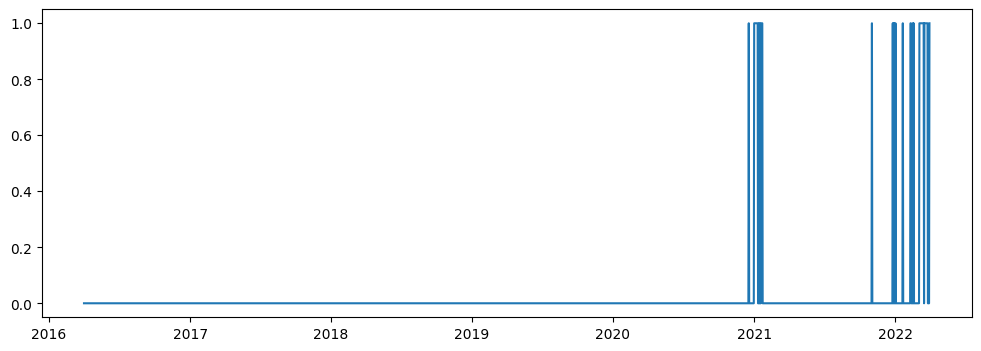

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(u_dict["Tokyo"][10])
plt.show()

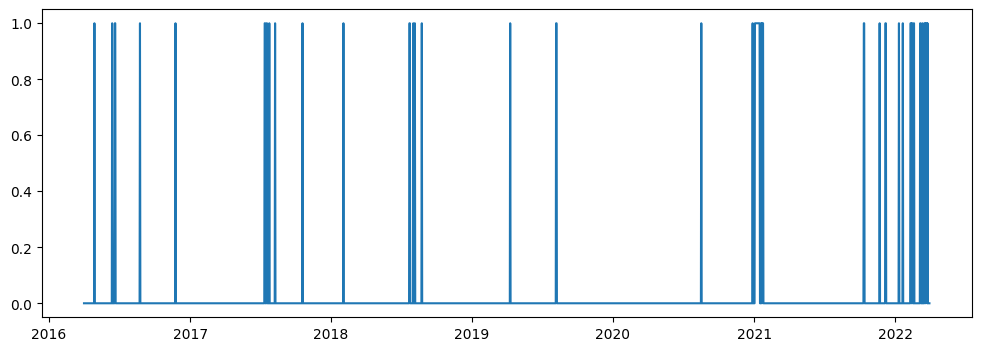

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(u_dict["Tokyo"][24])
plt.show()

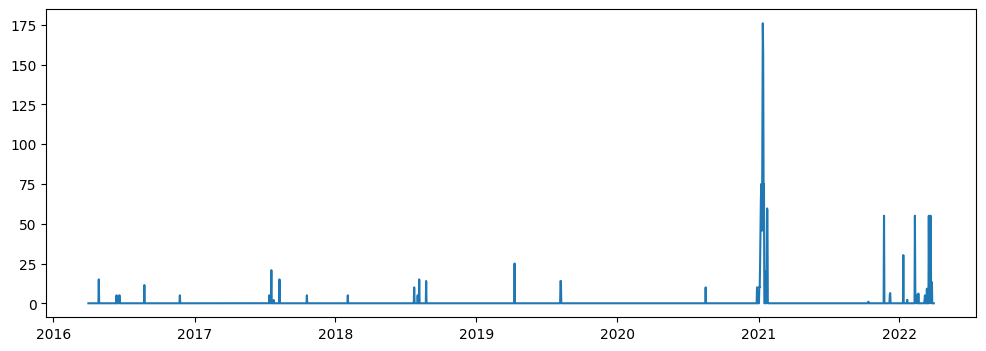

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(x_dict["Tokyo"][24])
plt.show()

In [ ]:
# indexを列に戻す
spike_long_reset = spike_long.reset_index()

# 保存
spike_long_reset.to_csv(
    (PROJECT_DATA_DIR / "processed/spike_long.csv"), index=False, encoding="utf-8"
)

print("spike_long.csv saved")

spike_long.csv saved


In [12]:
from pathlib import Path

output_dir = PROJECT_DATA_DIR / "processed/u_dict"
output_dir.mkdir(parents=True, exist_ok=True)

for area, df_area in u_dict.items():
    file_path = output_dir / f"u_{area}.csv"
    df_area.to_csv(file_path, encoding="utf-8")

print("u_dict CSVs saved")

u_dict CSVs saved


In [13]:
output_dir = PROJECT_DATA_DIR / "processed/x_dict"
output_dir.mkdir(parents=True, exist_ok=True)

for area, df_area in x_dict.items():
    file_path = output_dir / f"x_{area}.csv"
    df_area.to_csv(file_path, encoding="utf-8")

print("x_dict CSVs saved")

x_dict CSVs saved
